In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.model_selection import train_test_split 

# from ALT_F_BIND_chromo_vertex_nuclear_competitive_2_density import *
from binding_state_calc import *
import seaborn as sns

# Introduction:
Every cell in the human body shares the same DNA, yet manages to differentiate into hundreds of cell types. This differentiation is possible due to 
epigenetic modifications. We take a simplified, bottom-up approach to understand the impact of epigenetics: in the nucleus, DNA exists in a compact form 
called chromatin, where it is wound around proteins called nucleosomes. These nucleosomes have histone tails which can be chemically modified, and certain modifications encourage the binding of certain reader proteins (Figure 1). These reader proteins can attract or repel each other, making certain chromatin regions more condense. Condensed regions are unable to be transcribed, and thus the genes within are not expressed (Figure 2). So, by altering the epigenetic modifications (or “marks”), and therefore the binding of the reader proteins, the cell can alter which genes are expressed. Greater understanding of this process could enable therapeutic interventions. 

Previous work has applied machine learning methods, including random forests and neural networks, to predict chromosomal configuration from genomic data, specifically epigenetic modifications (“marks”) (1,2). Marks are a convenient model input due to the abundance of data available through sources such as the Encyclopedia of DNA Elements (ENCODE) project. However, these works fail to consider the role of binding proteins, which are in fact responsible for altering the chromosome configuration through their interactions. By applying statistical mechanical theory and inferring certain energetic parameters, the binding profile of these proteins can be inferred. __The goal of this project is to use either the mark profile or the binding profile (continuous-valued arrays) to predict the Hi-C map (either continuous or binary tensor).__
It is hypothesized that a model trained on the more-relevant binding profile will outperform a model trained on the mark profile.
Efforts are divided into two studies. The first is a preliminary study focused on simple, interpretable machine learning models, with the hope of gaining insight into the biology of the system. The second focused on more powerful multi-layer perceptrons.


# Data Acquisition and Preprocessing

This analysis focuses on chromosome 16 of cell line Gm12878 (human lymphoblastoid). For this cell line there is ChIP-seq data available on H3K9me3 marks. This data is continuous, and was thresholded to match expectations of the biological system- either 0, 1, or 2 marks per nucleosome. 
From the discretized mark profile, the binding state of the corresponding reader protein, heterochromatin protein 1 (HP1), can be calculated. The transfer-matrix method is employed, where HP1-HP1 interactions,  HP1-H3K9me3 interactions, and HP1 chemical potential are key parameters.  
Chromosome configuration is represented using Hi-C, which shows the amount of contact between bins of nucleosomes along the chromatin chain (after various normalization techniques are applied). This data can be kept continuous or made discrete depending on the ML technique.


## Prepare H3K9me3 (mark) profile

In [8]:
# bigwig file from quinn bottom up paper, then converted to bedgraph using bigWigToBedGraph from UCSC command line tool on WSL
h3k9me3_data = pd.read_csv('output.bedGraph', sep="\t", header=None)
h3k9me3_data.columns = ["chromosome", "start", "end", "value"]

# isolate chromosome 16
chr16_h3k9me3_data = h3k9me3_data[h3k9me3_data["chromosome"] == "chr16"] #.groupby("chromosome")
chr16_h3k9me3_data.sort_values("start", inplace=True)

# convert matrix of ranges into 1d array
array_size = chr16_h3k9me3_data['end'].max() 
h3k9me3_signal_bp = np.zeros(array_size)

# for each row, we create a range from start to end and assign the value
starts = chr16_h3k9me3_data['start'].values
ends = chr16_h3k9me3_data['end'].values
values = chr16_h3k9me3_data['value'].values

# create an array of indices from all ranges
indices = np.concatenate([np.arange(s, e) for s, e in zip(starts, ends)])
repeated_values = np.repeat(values, ends - starts)

# assign the values to the appropriate positions in result_array
np.add.at(h3k9me3_signal_bp, indices, repeated_values)
print(h3k9me3_signal_bp)
print(array_size)

# sum over nucleosomes
bp_per_nuc = 200
trimmed_size = (h3k9me3_signal_bp.size // bp_per_nuc) * bp_per_nuc
# print(trimmed_size)
reshaped_arr = h3k9me3_signal_bp[:trimmed_size].reshape(-1, bp_per_nuc)

# sum along the rows
h3k9me3_signal_nuc = np.sum(reshaped_arr, axis=1)

C:\Users\tmhab\AppData\Local\Temp\ipykernel_6000\1793724463.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr16_h3k9me3_data.sort_values("start", inplace=True)


[0.   0.   0.   ... 0.56 0.56 0.56]
90294025


In [10]:
num_nucs = len(h3k9me3_signal_nuc)

one_mark_cutoff = 220
two_mark_cutoff = one_mark_cutoff*2
print("# NO mark nucs: ", np.sum(h3k9me3_signal_nuc<one_mark_cutoff))
print("# one mark nucs: ", np.sum(1*(h3k9me3_signal_nuc>=one_mark_cutoff) * 1*(h3k9me3_signal_nuc<two_mark_cutoff)))
print("# two mark nucs: ", np.sum(h3k9me3_signal_nuc>=two_mark_cutoff))

marks_1 = np.zeros(num_nucs)

marks_1[np.where(h3k9me3_signal_nuc<one_mark_cutoff)] = 0
marks_1[np.where(1*(h3k9me3_signal_nuc>=one_mark_cutoff) * 1*(h3k9me3_signal_nuc<two_mark_cutoff))] = 1
marks_1[np.where(h3k9me3_signal_nuc>=two_mark_cutoff)] = 2
# np.sum(h3k9me3_signal_nuc>=two_mark_cutoff)

# NO mark nucs:  189916
# one mark nucs:  99726
# two mark nucs:  161828


<Figure size 1000x800 with 0 Axes>

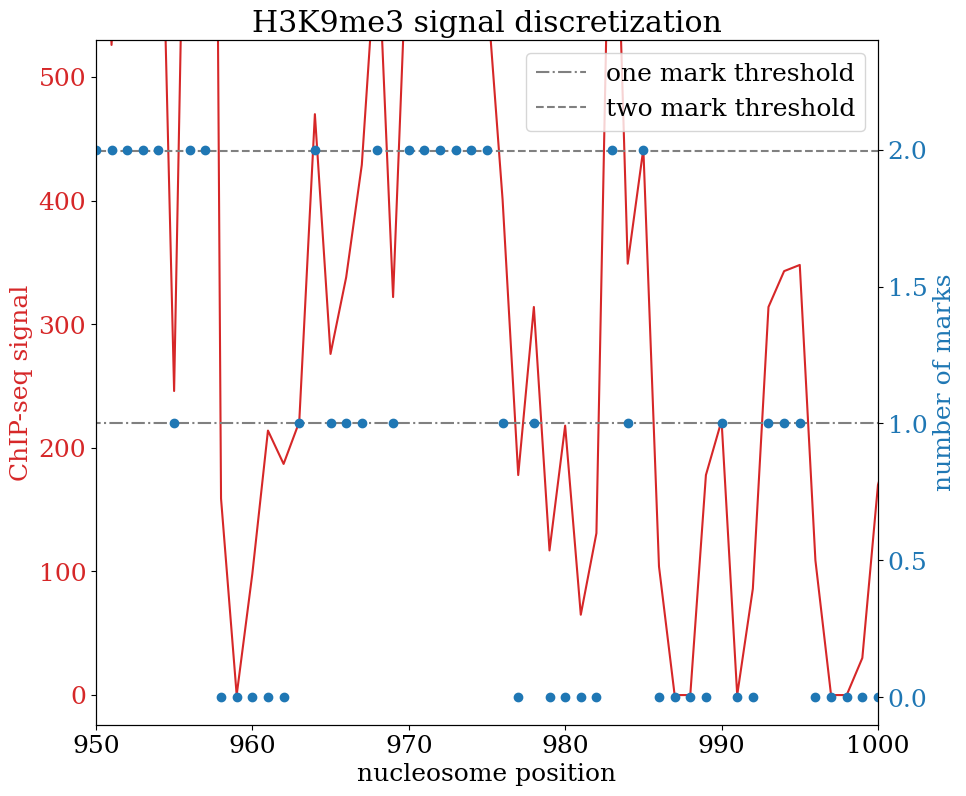

In [11]:
plt.figure(figsize=(10,8))
font = {'family' : 'serif',
        'weight':'normal',
        'size': 18}
plt.rc('font', **font)
fig, ax1 = plt.subplots(figsize=(10, 8))

plt.xlim(950,1000)
plt.ylim(-24,one_mark_cutoff*2+90)

color = 'tab:red'
ax1.set_xlabel('nucleosome position')
ax1.set_ylabel("ChIP-seq signal", color=color)
ax1.plot(np.arange(len(h3k9me3_signal_nuc)), h3k9me3_signal_nuc, color = color)
ax1.tick_params(axis='y', labelcolor=color)
plt.hlines(one_mark_cutoff, 0,1000, linestyle = "-.", color = "grey", label = "one mark threshold")
plt.hlines(one_mark_cutoff*2, 0,1000, linestyle = "--", color = "grey", label = "two mark threshold")
plt.legend(loc="upper right")

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
plt.ylim(-.1,2.4)
color = 'tab:blue'
ax2.set_ylabel('number of marks', color=color)  # we already handled the x-label with ax1
ax2.scatter(np.arange(len(marks_1)), marks_1, label = "cutoff")
ax2.tick_params(axis='y', labelcolor=color)

# plt.xlabel("nucleosome position")
# plt.ylabel("H3K9me3 ChIP-seq signal")

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title("H3K9me3 signal discretization")
plt.show()

## Calculate HP1 (reader protein) binding states

In [26]:
bp_per_nuc = 200

# adjustable parameter depending on Hi-C resolution
# binding_resolution = 1e6 #1mb
# binding_resolution = 500e3 # 500kb
# binding_resolution = 100e3 # 500kb
# binding_resolution = 50e3 #50kb
binding_resolution = 5e3 # 5kb

nuc_per_bin = int(binding_resolution / (bp_per_nuc)) # nuc per bin.    [resolution] = bp per bin, bp_per_nuc = 200
print(nuc_per_bin)

25


In [ ]:
%%time
# calculating averaged binding states based on resolution set above
mlp_data_mark_1 = marks_1[:(len(marks_1)//nuc_per_bin)*nuc_per_bin].reshape(-1,nuc_per_bin)#.astype(sigma_dt)
mark_1_avgd = np.mean(mlp_data_mark_1, axis=1)

sig = mark_1_avgd/2 # should be from 0 to 1; percent marked#[:10]
mu_hp1 = -5
mu_prc1 = -100 # only considering a single reader protein (HP1)
ea = -1.52
eb = 0#-1.52

j_aa = -4
j_bb = 0
j_ab = 0

f_ref = np.min(np.array([j_aa, j_bb, j_ab, ea, eb]))
s_bind_hp1_avgd, phib = eval_phi(sig, mu_hp1, mu_prc1, ea, eb, j_aa, j_bb, j_ab, f_ref)

In [ ]:
fig = plt.figure()
plt.figure(figsize=(10,8))

font = {'family' : 'serif',
        'weight':'normal',
        'size': 18}
plt.rc('font', **font)

plt.plot(np.arange(len(s_bind_hp1_avgd)), mark_1_avgd, label = "ave H3K9me3")
plt.plot(np.arange(len(s_bind_hp1_avgd)), s_bind_hp1_avgd, label = "ave HP1 binding")

plt.xlabel("binned nuceosome position")
plt.ylabel("avg val")
plt.title("mark profile vs binding profile, $\mu_{HP1}$ = %s, resolution = %s" % (mu_hp1, binding_resolution))
plt.legend()

## Prepare Hi-C data

In [ ]:
resolution = 1e6 #1mb
Hi_c_raw_obs = pd.read_csv(r"C:\Users\tmhab\wlcsim_membrane\config_binding\Hi-C_data_chr_16\chr16_1mb.RAWobserved", sep="\t", header=None)
Hi_c_raw_obs.columns = ["i","j",r"$M_{ij}$"]
Hi_c_KRnorm = np.loadtxt(r"C:\Users\tmhab\wlcsim_membrane\config_binding\Hi-C_data_chr_16\chr16_1mb.KRnorm")
# Hi_c_raw_exp = pd.read_csv(r"C:\Users\tmhab\wlcsim_membrane\config_binding\Hi-C_data_chr_16\chr16_1mb.RAWexpected", sep="\t", header=None)
# Hi_c_raw_exp.columns = ["i","j",r"$M_{ij}$"]
Hi_c_KRexpected = np.loadtxt(r"C:\Users\tmhab\wlcsim_membrane\config_binding\Hi-C_data_chr_16\chr16_1mb.KRexpected")

# resolution = 500e3 #500kb
# binding_resolution == resolution
# Hi_c_raw_obs = pd.read_csv(r"C:\Users\tmhab\wlcsim_membrane\config_binding\Hi-C_data_chr_16\chr16_500kb.RAWobserved", sep="\t", header=None)
# Hi_c_raw_obs.columns = ["i","j",r"$M_{ij}$"]
# Hi_c_KRnorm = np.loadtxt(r"C:\Users\tmhab\wlcsim_membrane\config_binding\Hi-C_data_chr_16\chr16_500kb.KRnorm")
# Hi_c_KRexpected = np.loadtxt(r"C:\Users\tmhab\wlcsim_membrane\config_binding\Hi-C_data_chr_16\chr16_500kb.KRexpected")

# resolution = 100e3 #100kb
# binding_resolution == resolution
# Hi_c_raw_obs = pd.read_csv(r"C:\Users\tmhab\wlcsim_membrane\config_binding\Hi-C_data_chr_16\chr16_100kb.RAWobserved", sep="\t", header=None)
# Hi_c_raw_obs.columns = ["i","j",r"$M_{ij}$"]
# Hi_c_KRnorm = np.loadtxt(r"C:\Users\tmhab\wlcsim_membrane\config_binding\Hi-C_data_chr_16\chr16_100kb.KRnorm")
# Hi_c_KRexpected = np.loadtxt(r"C:\Users\tmhab\wlcsim_membrane\config_binding\Hi-C_data_chr_16\chr16_100kb.KRexpected")

# resolution = 50e3 #50kb
# binding_resolution == resolution
# Hi_c_raw_obs = pd.read_csv(r"C:\Users\tmhab\wlcsim_membrane\config_binding\Hi-C_data_chr_16\chr16_50kb.RAWobserved", sep="\t", header=None)
# Hi_c_raw_obs.columns = ["i","j",r"$M_{ij}$"]
# Hi_c_KRnorm = np.loadtxt(r"C:\Users\tmhab\wlcsim_membrane\config_binding\Hi-C_data_chr_16\chr16_50kb.KRnorm")
# Hi_c_KRexpected = np.loadtxt(r"C:\Users\tmhab\wlcsim_membrane\config_binding\Hi-C_data_chr_16\chr16_50kb.KRexpected")

# resolution = 5e3 #5kb
# # binding_resolution == resolution
# Hi_c_raw_obs = pd.read_csv(r"C:\Users\tmhab\wlcsim_membrane\config_binding\Hi-C_data_chr_16\chr16_5kb.RAWobserved", sep="\t", header=None)
# Hi_c_raw_obs.columns = ["i","j",r"$M_{ij}$"]
# Hi_c_KRnorm = np.loadtxt(r"C:\Users\tmhab\wlcsim_membrane\config_binding\Hi-C_data_chr_16\chr16_5kb.KRnorm")
# Hi_c_KRexpected = np.loadtxt(r"C:\Users\tmhab\wlcsim_membrane\config_binding\Hi-C_data_chr_16\chr16_5kb.KRexpected")

assert(binding_resolution == resolution)

### KR normalization of observed Hi-C data

In [ ]:
Hi_c_Kr_obs = Hi_c_raw_obs[r"$M_{ij}$"].values / (Hi_c_KRnorm[(Hi_c_raw_obs["i"].values // resolution).astype(int)]*Hi_c_KRnorm[(Hi_c_raw_obs["j"].values // resolution).astype(int)])

In [ ]:
Hi_c_raw_obs[r"$M_{ij}^{KR}$"] = Hi_c_Kr_obs

### Obs/Exp

In [ ]:
# observed/expected correction
i_j_diff = Hi_c_raw_obs["i"].values - Hi_c_raw_obs["j"].values
Kr_indices = (i_j_diff // resolution).astype(int)
Hi_c_Kr_OE = Hi_c_Kr_obs / Hi_c_KRexpected[Kr_indices]
Hi_c_raw_obs[r"$(O/E)^{KR}$"] = Hi_c_Kr_OE

In [ ]:
fig = plt.figure()
plt.figure(figsize=(10,8))

font = {'family' : 'serif',
        'weight':'normal',
        'size': 18}
plt.rc('font', **font)

# 1. Create a pivot table to reshape the data into a grid for the heatmap
heatmap_data = Hi_c_raw_obs.pivot(columns='j', index='i', values=r'$M_{ij}$')

# 2. Plot the heatmap using imshow
plt.imshow(heatmap_data, cmap='cool', interpolation='nearest', origin='lower')

# Add color bar to indicate intensity values
plt.colorbar(label='signal')

# 3. Add labels and title
plt.xlabel('i')
plt.ylabel('j')
plt.title(r'$M_{ij}$ raw, res = %s' % resolution)

# Show the plot
plt.show()

In [ ]:
fig = plt.figure()
plt.figure(figsize=(10,8))

font = {'family' : 'serif',
        'weight':'normal',
        'size': 18}
plt.rc('font', **font)

# 1. Create a pivot table to reshape the data into a grid for the heatmap
heatmap_data = Hi_c_raw_obs.pivot(columns='j', index='i', values=r'$M_{ij}^{KR}$')

# 2. Plot the heatmap using imshow
plt.imshow(heatmap_data, cmap='cool', interpolation='nearest', origin='lower')

# Add color bar to indicate intensity values
plt.colorbar(label='signal')

# 3. Add labels and title
plt.xlabel('i')
plt.ylabel('j')
plt.title(r'$M_{ij}^{KR}$, res = %s' % resolution)

# Show the plot
plt.show()

In [ ]:
fig = plt.figure()
plt.figure(figsize=(10,8))

font = {'family' : 'serif',
        'weight':'normal',
        'size': 18}
plt.rc('font', **font)

# 1. Create a pivot table to reshape the data into a grid for the heatmap
heatmap_data = Hi_c_raw_obs.pivot(columns='j', index='i', values=r"$(O/E)^{KR}$")

# 2. Plot the heatmap using imshow
plt.imshow(heatmap_data, cmap="cool", interpolation='nearest', origin='lower')

# Add color bar to indicate intensity values
plt.colorbar(label='signal')

# 3. Add labels and title
plt.xlabel('i')
plt.ylabel('j')
plt.title(r"$Hi-C \ map; (O/E)^{KR}$, res = %s" % resolution)

# Show the plot
plt.show()

# Model Development

## Logistic regression

Logistic regression model with a sigmoid nonlinearity. A sum of squared error loss was used, with a simulated annealing minimization procedure. The goal was that the learned parameter would give insight to the energetics of the system. 

Define a cost function $J = \sum_{ij} (s_{ij} - f_{ij})^2$ where $s_{ij}$ is the true Hi-C observation for the ijth bin and $f_{ij}$ is the output of the activation function (sigmoid) for the same bin. 
$f_{ij}(b_{ij}) = \frac{1}{1+\exp(-b_{ij})}$ is a function of the ijth mark or bind array $b_{ij} = \vec{\sigma}_i \mathbf{A} \vec{\sigma}_j + A_0$, where $\sigma_i$ is the mark or bind profile vector and $\mathbf{A}$ is a matrix and $A_0$ is a scalar, both of which need to be "learned".

Gradient ascent on the log likelihood could not be used because the assumption of sample independence does not hold; the contact at one bin is related to the contact at another bin, as all nucleosomes reside on the same DNA chain. Gradient descent on SSE was not used to avoid local minima. 

10/24 EDIT:  $\sigma_i$ is the mark or bind profile vector, as in each entry is the averaged mark or bind content for a specific mark or bind type [h3k9me3, h3k27me3, ...] ; [hp1, prc1,...]

In [ ]:
# faster einsum
def func_dot_einsum(A, sig_i, sig_j):
    Y = sig_i.dot(A)
    return np.einsum('ij,ij->i', Y, sig_j)

# A_0 = 0
# WHERE sigma is array of averaged mark 
def cost_function(As, params):
    # num_marks = 1
    [sig_i_avgd, sig_j_avgd, s_ij, num_marks] = params

    A_0 = As[-1]
    A_mat = As[0:len(As)-1].reshape(num_marks, num_marks)
    
    if num_marks == 1:
        b_ij = sig_i_avgd*A_mat[0]*sig_j_avgd+A_0
        # print(b_ij)
    else:
        A_mat[1,0] = A_mat[0,1] #enforce symmetry
        b_ij = np.einsum("ij,jk,ik->i", sig_i_avgd, A_mat, sig_j_avgd) + A_0 # low mem, GOOD FOR 5kb
        # b_ij = func_dot_einsum(A_mat, sig_i_avgd, sig_j_avgd) + A_0 # faster hybrid of einsum, again memory issue; GOOD FOR 10kb AND ABOVE

    f_ij = 1/(1 + np.exp(-b_ij)) #sigmoid

    # J = np.sum((s_ij - f_ij)**2) 

    classified = np.zeros(len(f_ij))
    classified[f_ij > 0.5] = 1
    J = np.sum((s_ij - classified)**2) 
    return J


def simulated_annealing(objective, params, bounds, n_iterations, step_size, temp):
     # generate an initial point
     best = bounds#bounds[:, 0] + rand(len(bounds)) * (bounds[:, 1] - bounds[:, 0])
     # evaluate the initial point
     best_eval = objective(best, params)
     # current working solution
     curr, curr_eval = best, best_eval
     # run the algorithm
     for i in range(n_iterations):
         # take a step
         cur_step = step_size/np.log(i+np.e) # decreasing step_size at iterations increase
         candidate = curr + np.random.randn(len(bounds)) * cur_step#step_size
         candidate_eval = objective(candidate, params)
         
         # check for new best solution
         if candidate_eval < best_eval:
             # store new best point
             best, best_eval = candidate, candidate_eval
             # report progress
             print('>%d f() = %.5f' % (i, best_eval))
             
         # difference between candidate and current point evaluation
         diff = candidate_eval - curr_eval
         # calculate temperature for current epoch
         # t = temp / float(i + 1) #linear
         t = temp/np.log(i+np.e) #log
         
         # calculate metropolis acceptance criterion
         metropolis = np.exp(-diff / t)
         # check if we should keep the new point
         if diff < 0 or np.random.rand() < metropolis:
             # store the new current point
             curr, curr_eval = candidate, candidate_eval
             
     return [best, best_eval]

In [ ]:
nuc_per_bin = int(resolution / (bp_per_nuc)) # nuc per bin.    [resolution] = bp per bin, bp_per_nuc = 200

# generate copy of Hi-c data where genomic position turned into {bin index precursor}
Hi_c_raw_obs_div = Hi_c_raw_obs.copy()
Hi_c_raw_obs_div = Hi_c_raw_obs_div.dropna()
Hi_c_raw_obs_div["i"] = (Hi_c_raw_obs_div["i"].values//resolution).astype(int)
Hi_c_raw_obs_div["j"] = (Hi_c_raw_obs_div["j"].values//resolution).astype(int)

#cutoff last bin so that mark data and hi-c data are same size
cutoff_bin = len(marks_1)//nuc_per_bin
Hi_c_raw_obs_div = Hi_c_raw_obs_div[Hi_c_raw_obs_div["i"] != cutoff_bin]
Hi_c_raw_obs_div = Hi_c_raw_obs_div[Hi_c_raw_obs_div["j"] != cutoff_bin]

i_combs = Hi_c_raw_obs_div["i"].values
j_combs = Hi_c_raw_obs_div["j"].values
Hi_C = Hi_c_raw_obs_div[r"$(O/E)^{KR}$"].values

#Turn Hi_C data into binary classification; 1 = contact, 0 = no
s_ij = np.zeros(len(Hi_C))
s_ij[Hi_C > np.mean(Hi_C)] = 1 # Hi_C into binary classification, based on mean

num_marks = 1

sig_mark_i = mark_1_avgd[i_combs]
sig_mark_j = mark_1_avgd[j_combs]

sig_bind_i = s_bind_hp1_avgd[i_combs] 
sig_bind_j = s_bind_hp1_avgd[j_combs]

#single A matrix to describe all pairs

A = np.zeros((num_marks, num_marks))
A_0 = 0

if num_marks == 1:
    b_ij_mark = sig_mark_i*A[0]*sig_mark_i+A_0
    b_ij_bind = sig_bind_i*A[0]*sig_bind_i+A_0
    # print(b_ij)
else:
    raise Exception("only 1 mark implemented")

f_ij_mark = 1/(1 + np.exp(-b_ij_mark)) #sigmoid
f_ij_bind = 1/(1 + np.exp(-b_ij_bind)) #sigmoid

J_mark = np.sum((s_ij - f_ij_mark)**2) # cost function. CANT instead do maximum likelihood approach b/c points are not independent
J_bind = np.sum((s_ij - f_ij_bind)**2) # cost function. could instead do maximum likelihood approach b/c points are not independent

In [ ]:
Hi_c_raw_obs_div[r"s_{ij}"] = s_ij

fig = plt.figure()
plt.figure(figsize=(10,8))

font = {'family' : 'serif',
        'weight':'normal',
        'size': 18}
plt.rc('font', **font)

heatmap_data = Hi_c_raw_obs_div.pivot(columns='j', index='i', values=r"s_{ij}")

plt.imshow(heatmap_data, cmap="cool", interpolation='nearest', origin='lower')

plt.colorbar(label='signal')
plt.xlabel('i')
plt.ylabel('j')
plt.title(r"$Hi-C \ map; binary$, res = %s" % resolution)

plt.show()

In [ ]:
# train model

sig_mark_i = mark_1_avgd[i_combs]
sig_mark_j = mark_1_avgd[j_combs]

sig_bind_i = s_bind_hp1_avgd[i_combs] 
sig_bind_j = s_bind_hp1_avgd[j_combs]

As = np.zeros(num_marks**2+1)# Initial guess.


params_uniq_mark = [sig_mark_i, sig_mark_j, s_ij, num_marks]   
params_uniq_bind = [sig_bind_i, sig_bind_j, s_ij, num_marks]   

step_size = 10
n_iter = 1000
temp = 1000000
# best, best_eval = simulated_annealing(cost_function, params_uniq, As,n_iter,step_size,temp)

best_mark, best_eval_mark = simulated_annealing(cost_function, params_uniq_mark, As,n_iter,step_size,temp)
best_bind, best_eval_bind = simulated_annealing(cost_function, params_uniq_bind, As,n_iter,step_size,temp)
#TODO: either change s_ij to a 2d matrix or b_ij into 1d arrays with all points of 2d matrix. think latter is easier

In [ ]:
# evaluate model

A_0_best_mark = best_mark[-1]
A_mat_best_mark = best_mark[0:len(best_mark)-1].reshape(num_marks, num_marks)

A_0_best_bind = best_bind[-1]
A_mat_best_bind = best_bind[0:len(best_bind)-1].reshape(num_marks, num_marks)

b_ij_mark = (sig_mark_i*A_mat_best_mark[0]*sig_mark_j)+A_0_best_mark
b_ij_bind = (sig_bind_i*A_mat_best_bind[0]*sig_bind_i)+A_0_best_bind


f_ij_mark = 1/(1 + np.exp(-b_ij_mark)) #sigmoid
f_ij_bind = 1/(1 + np.exp(-b_ij_bind)) #sigmoid


classified_mark = np.zeros(len(f_ij_mark))
classified_mark[f_ij_mark > 0.5] = 1

classified_bind = np.zeros(len(f_ij_bind))
classified_bind[f_ij_bind > 0.5] = 1

# R2 for regression
# SS_res = np.sum((s_ij - classified)**2)
# SS_tot = np.sum((s_ij - np.mean(s_ij))**2)

# R2 = 1 - (SS_res/SS_tot) # cost function. could instead do maximum likelihood approach
# R2
# print("NOT GOOD METRIC FOR CLASSIFICATION")


# # BIND confusion matrix
# true_pos_bind  = np.sum((s_ij == np.ones(len(s_ij))) * (classified_bind   == np.ones(len(s_ij))))
# true_neg_bind  = np.sum((s_ij == np.zeros(len(s_ij))) * (classified_bind   == np.zeros(len(s_ij))))
# false_pos_bind  = np.sum((s_ij == np.zeros(len(s_ij))) * (classified_bind   == np.ones(len(s_ij))))
# false_neg_bind  = np.sum((s_ij == np.ones(len(s_ij))) * (classified_bind   == np.zeros(len(s_ij))))

# recall_bind  = true_pos_bind  / (true_pos_bind  + false_neg_bind ) #sensitivity
# precision_bind  = true_pos_bind  / (true_pos_bind  + false_pos_bind ) 

# f1_bind   = (2 * precision_bind  * recall_bind ) / (precision_bind  + recall_bind )
# # f1_mark

# accuracy_bind   = (true_pos_bind  + true_neg_bind ) / (true_pos_bind  + true_neg_bind  + false_pos_bind  + false_neg_bind)


# MARK confusion matrix
true_pos_mark = np.sum((s_ij == np.ones(len(s_ij))) * (classified_mark == np.ones(len(s_ij))))
true_neg_mark = np.sum((s_ij == np.zeros(len(s_ij))) * (classified_mark == np.zeros(len(s_ij))))
false_pos_mark = np.sum((s_ij == np.zeros(len(s_ij))) * (classified_mark == np.ones(len(s_ij))))
false_neg_mark = np.sum((s_ij == np.ones(len(s_ij))) * (classified_mark == np.zeros(len(s_ij))))

recall_mark = true_pos_mark / (true_pos_mark + false_neg_mark) #sensitivity
precision_mark = true_pos_mark / (true_pos_mark + false_pos_mark) 

f1_mark = (2 * precision_mark * recall_mark) / (precision_mark + recall_mark)
# f1_bind
accuracy_mark = (true_pos_mark + true_neg_mark) / (true_pos_mark + true_neg_mark + false_pos_mark + false_neg_mark)

# BIND confusion matrix
true_pos_bind  = np.sum((s_ij == np.ones(len(s_ij))) * (classified_bind   == np.ones(len(s_ij))))
true_neg_bind  = np.sum((s_ij == np.zeros(len(s_ij))) * (classified_bind   == np.zeros(len(s_ij))))
false_pos_bind  = np.sum((s_ij == np.zeros(len(s_ij))) * (classified_bind   == np.ones(len(s_ij))))
false_neg_bind  = np.sum((s_ij == np.ones(len(s_ij))) * (classified_bind   == np.zeros(len(s_ij))))

recall_bind  = true_pos_bind  / (true_pos_bind  + false_neg_bind ) #sensitivity
precision_bind  = true_pos_bind  / (true_pos_bind  + false_pos_bind ) 

f1_bind   = (2 * precision_bind  * recall_bind ) / (precision_bind  + recall_bind )
# f1_mark

accuracy_bind   = (true_pos_bind  + true_neg_bind ) / (true_pos_bind  + true_neg_bind  + false_pos_bind  + false_neg_bind)

### performance

In [ ]:
def find_acc_f1(best_bind):
    num_marks=1
    A_0_best_bind = best_bind[-1]
    A_mat_best_bind = best_bind[0:len(best_bind)-1].reshape(num_marks, num_marks)
    b_ij_bind = (sig_bind_i*A_mat_best_bind[0]*sig_bind_i)+A_0_best_bind
    f_ij_bind = 1/(1 + np.exp(-b_ij_bind)) #sigmoid
    classified_bind = np.zeros(len(f_ij_bind))
    classified_bind[f_ij_bind > 0.5] = 1
    # BIND confusion matrix
    true_pos_bind  = np.sum((s_ij == np.ones(len(s_ij))) * (classified_bind   == np.ones(len(s_ij))))
    true_neg_bind  = np.sum((s_ij == np.zeros(len(s_ij))) * (classified_bind   == np.zeros(len(s_ij))))
    false_pos_bind  = np.sum((s_ij == np.zeros(len(s_ij))) * (classified_bind   == np.ones(len(s_ij))))
    false_neg_bind  = np.sum((s_ij == np.ones(len(s_ij))) * (classified_bind   == np.zeros(len(s_ij))))

    # print("# ones:", np.sum((classified_bind   == np.ones(len(s_ij)))))
    # print("# zeros:", np.sum((classified_bind   == np.zeros(len(s_ij)))))

    recall_bind  = true_pos_bind  / (true_pos_bind  + false_neg_bind ) #sensitivity
    precision_bind  = true_pos_bind  / (true_pos_bind  + false_pos_bind ) 
    
    f1_bind   = (2 * precision_bind  * recall_bind ) / (precision_bind  + recall_bind )
    # f1_mark
    
    accuracy_bind   = (true_pos_bind  + true_neg_bind ) / (true_pos_bind  + true_neg_bind  + false_pos_bind  + false_neg_bind)
    return accuracy_bind, f1_bind

In [ ]:
%%time
params_uniq_mark = [sig_mark_i, sig_mark_j, s_ij, num_marks]   
params_uniq_bind = [sig_bind_i, sig_bind_j, s_ij, num_marks]   

step_size = 10
n_iter = 1000
temp = 100000000

As = np.zeros(num_marks**2+1)# Initial guess.


# n_iter_arr = np.array([1e2, 1e3, 1e4, 1e5, 1e6, 1e7], dtype=int)
# n_iter_arr = np.array([1e2, 1e3, 1e4, 1e5], dtype=int)
# n_iter_arr = np.array(np.logspace(2, 7, 10), dtype=int)
n_iter_arr = np.array(np.logspace(2, 6, 10), dtype=int)

acc_arr_mark = np.zeros(len(n_iter_arr))
acc_arr_bind = np.zeros(len(n_iter_arr))

f1_arr_mark = np.zeros(len(n_iter_arr))
f1_arr_bind = np.zeros(len(n_iter_arr))
for i, n_iter in enumerate(n_iter_arr):
# best, best_eval = simulated_annealing(cost_function, params_uniq, As,n_iter,step_size,temp)
    
    best_mark, best_eval_mark = simulated_annealing(cost_function, params_uniq_mark, As,n_iter,step_size,temp)
    best_bind, best_eval_bind = simulated_annealing(cost_function, params_uniq_bind, As,n_iter,step_size,temp)
    
    acc_bind, f1_bind = find_acc_f1(best_bind)
    acc_mark, f1_mark = find_acc_f1(best_mark)
    
    acc_arr_mark[i] = acc_mark
    acc_arr_bind[i] = acc_bind

    f1_arr_mark[i] = f1_mark
    f1_arr_bind[i] = f1_bind

In [ ]:
fig = plt.figure()
plt.figure(figsize=(10,8))

font = {'family' : 'serif',
        'weight':'normal',
        'size': 18}
plt.rc('font', **font)

plt.plot(n_iter_arr, acc_arr_mark, label = "mark")
plt.plot(n_iter_arr, acc_arr_bind, label = "bind", linestyle = "--")
plt.hlines(np.sum((s_ij == np.zeros(len(s_ij)))) / len(s_ij), n_iter_arr[0], n_iter_arr[-1], label = "pred = all 0s ", color = "black", linestyle = "--")
plt.xscale("log")
plt.xlabel("n_iterations")
plt.ylabel("accuracy")
plt.title("log_reg comparison")
plt.legend()
# plt.savefig('acc.png')

This model is underfit. The most accurate model trained is based on the mark profiles, but only predicts no-contact regardless of the input data. Cannot guarantee reaching global minimum of the loss function with the simulated annealing technique, but varying the hyperparameters of temperature and the number of iterations over many decades does not meaningfully change the accuracy. This model is not complex enough.

## Loacally weighted linear regression

Locally weighted linear regression learned by normal equation of SSE loss was used, with weights of the form $w_i = \exp(-||x_i - x||^2 / 2 \tau^2 )$ or $w_i = ||x_i - x||^2 / 2 \tau^2$  and model of form $b_{ij} = \theta \sigma_i \sigma_j + \theta_0$ . This technique was of interest as it can fit complex functions with few “parameters”. The goal was to see if, by looking at how the parameters change depending on the query point, I could better understand the physics of the protein-protein interactions.

In [ ]:
class LocallyWeightedLinearRegression():
    """Locally Weighted Regression (LWR).

    Example usage:
        > clf = LocallyWeightedLinearRegression(tau)
        > clf.fit(x_train, y_train)
        > clf.predict(x_eval)
    """

    def __init__(self, tau):
        super(LocallyWeightedLinearRegression, self).__init__()
        self.tau = tau
        self.x = None
        self.y = None

    def fit(self, x, y):
        """Fit LWR by saving the training set.

        """
        self.x = x #
        self.y = y

    def predict(self, x):
        """Make predictions given inputs x.

        Args:
            x: Inputs of shape (m, n).

        Returns:
            Outputs of shape (m,).
        """
        
        if self.x is None or self.y is None:
            raise RuntimeError('Must call fit before predict.')

        pred_arr = np.zeros(np.shape(x)[0])
        for i in range(np.shape(x)[0]): # for each potential query point
            x_q = x[i,:]
            # generate weights for that query point
            diff = self.x - x_q
            # weights = np.exp(  (- np.sum((self.x-x_q)**2, axis = 1) ) / (2*self.tau**2)   )
            weights = np.sum((self.x-x_q)**2, axis = 1) / (2*self.tau**2)

            #train model
            W = np.diag(weights)
            X = self.x
            XWX_inv = np.linalg.inv(X.T.dot(W.dot(X)))
            
            # theta = (X^T W X)^-1 X^T W y
            theta = XWX_inv.dot(X.T.dot(W.dot(self.y)))
            pred_q = theta.T.dot(x_q)
            pred_arr[i] = pred_q

        return pred_arr

In [ ]:
# np.shape(sig_mark_i*sig_mark_j)
x_mark = np.zeros((len(sig_mark_i*sig_mark_j), 2))
x_mark[:,0] = sig_mark_i*sig_mark_j
x_mark[:,1] = 1

x_bind = np.zeros((len(sig_bind_i*sig_bind_j), 2))
x_bind[:,0] = sig_bind_i*sig_bind_j
x_bind[:,1] = 1

y_binary = s_ij
y = Hi_C

In [ ]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(x_mark,y ,  
                                   test_size=0.25,  
                                   shuffle=True) 

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(x_bind,y ,  
                                   test_size=0.25,  
                                   shuffle=True) 
  

In [ ]:
%%time
tau_array = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
# tau_array = [0.5e-1, 1e-1, 1, 10]
train_acc_m_arr = np.zeros_like(tau_array) - 1
test_acc_m_arr = np.zeros_like(tau_array) - 1
train_acc_b_arr = np.zeros_like(tau_array) - 1
test_acc_b_arr = np.zeros_like(tau_array) - 1

for i, tau in enumerate(tau_array):
    clf_mark = LocallyWeightedLinearRegression(tau)
    clf_mark.fit(X_train_m, y_train_m)
    
    x_eval = X_test_m
    p_eval_m = clf_mark.predict(x_eval)

    clf_bind = LocallyWeightedLinearRegression(tau)
    clf_bind.fit(X_train_b, y_train_b)
    
    x_eval = X_test_b
    p_eval_b = clf_bind.predict(x_eval)

    x_eval = X_train_m
    p_train_eval_m = clf_mark.predict(x_eval)    

    x_eval = X_train_b
    p_train_eval_b = clf_bind.predict(x_eval)
    
    train_acc_m = np.sum((p_train_eval_m - y_train_m)**2)
    train_acc_m_arr[i] = train_acc_m
    test_acc_m = np.sum((p_eval_m - y_test_m)**2)
    test_acc_m_arr[i]= test_acc_m
    train_acc_b = np.sum((p_train_eval_b - y_train_b)**2)
    train_acc_b_arr[i] = train_acc_b
    test_acc_b = np.sum((p_eval_b - y_test_b)**2)
    test_acc_b_arr[i] = test_acc_b
    print("ONE TAU DONE")

In [ ]:
# variance weights
fig = plt.figure()
plt.figure(figsize=(10,8))

font = {'family' : 'serif',
        'weight':'normal',
        'size': 18}
plt.rc('font', **font)

plt.xscale("log")

plt.plot(tau_array, train_acc_m_arr, color = "blue", label = "mark train")
plt.plot(tau_array, test_acc_m_arr, color = "blue", linestyle = "--", label = "mark test")

plt.plot(tau_array, train_acc_b_arr, color = "orange", label = "bind train")
plt.plot(tau_array, test_acc_b_arr, color = "orange", linestyle = "--", label = "bind test")

plt.xlabel(r"$\tau$")
plt.ylabel("SSE loss")
plt.title("lwr loss comparison")
plt.legend()

In [ ]:
fig = plt.figure()
plt.figure(figsize=(10,8))

font = {'family' : 'serif',
        'weight':'normal',
        'size': 18}
plt.rc('font', **font)

plt.xscale("log")

plt.plot(tau_array, train_acc_m_arr, color = "blue", label = "mark train")
plt.plot(tau_array, test_acc_m_arr, color = "blue", linestyle = "--", label = "mark test")

plt.plot(tau_array, train_acc_b_arr, color = "orange", label = "bind train")
plt.plot(tau_array, test_acc_b_arr, color = "orange", linestyle = "--", label = "bind test")

plt.xlabel(r"$\tau$")
plt.ylabel("SSE loss")
plt.title("lwr loss comparison")
plt.legend()

In [ ]:
# %%time
clf_mark = LocallyWeightedLinearRegression(tau)
clf_mark.fit(X_train_m, y_train_m)

x_eval = X_test_m
p_eval_m = clf_mark.predict(x_eval)

x_eval = X_train_m
p_train_eval_m = clf_mark.predict(x_eval)

In [ ]:
# %%time
# tau = .01
clf_bind = LocallyWeightedLinearRegression(tau)
clf_bind.fit(X_train_b, y_train_b)

x_eval = X_test_b
p_eval_b = clf_bind.predict(x_eval)

x_eval = X_train_b
p_train_eval_b = clf_bind.predict(x_eval)

In [ ]:
p_eval_m_plotting = p_eval_m[:28**2].reshape((28,28))
p_eval_b_plotting = p_eval_b[:28**2].reshape((28,28))
y_test_m_plotting = y_test_m[:28**2].reshape((28,28))
y_test_b_plotting = y_test_b[:28**2].reshape((28,28))

p_train_eval_m_plotting = p_train_eval_m[:49**2].reshape((49,49))
p_train_eval_b_plotting = p_train_eval_b[:49**2].reshape((49,49))
y_train_m_plotting = y_train_m[:49**2].reshape((49,49))
y_train_b_plotting = y_train_b[:49**2].reshape((49,49))
# p_eval_b  y_test_b

In [13]:
### comparison Hi-C maps (model predictions p vs actualy data y)

In [ ]:
fig = plt.figure()
plt.figure(figsize=(10,8))

font = {'family' : 'serif',
        'weight':'normal',
        'size': 18}
plt.rc('font', **font)


ax = sns.heatmap(p_train_eval_m_plotting)#, linewidth=0.25, cmap = "cool", xticklabels=mu2_array[min_ind:max_ind], yticklabels=mu1_array[min_ind:max_ind],\
                 # cbar_kws={'label':  r"$ \frac{1}{k^*} \ (nm)$"})#,\
                    # vmin=1/(k_vec[-1]), vmax=1/(k_vec[0]))

plt.ylabel("$i$")
plt.xlabel("$j$")
plt.title(r"$mark \ p_{train} $" )#+  ", $\chi = $" + \
          # str(np.round(chi, 2)) \
          # +  ", $v_{int} = $ [" + str(v_int[0]) + "," + str(v_int[1]) + "]" +\
          # "\n")


plt.show()


In [ ]:
fig = plt.figure()
plt.figure(figsize=(10,8))

font = {'family' : 'serif',
        'weight':'normal',
        'size': 18}
plt.rc('font', **font)


ax = sns.heatmap(y_train_m_plotting)#, linewidth=0.25, cmap = "cool", xticklabels=mu2_array[min_ind:max_ind], yticklabels=mu1_array[min_ind:max_ind],\
                 # cbar_kws={'label':  r"$ \frac{1}{k^*} \ (nm)$"})#,\
                    # vmin=1/(k_vec[-1]), vmax=1/(k_vec[0]))

plt.ylabel("$i$")
plt.xlabel("$j$")
plt.title(r"$mark \ y_{train}$" )#+  ", $\chi = $" + \
          # str(np.round(chi, 2)) \
          # +  ", $v_{int} = $ [" + str(v_int[0]) + "," + str(v_int[1]) + "]" +\
          # "\n")


plt.show()


This model also failed. This was apparent by the fact that the error on the trained data was much higher than the error on the test data, and that the training predictions were very different from the training Hi-C- see Figure 5 right. This may indicate that the binding proteins or marks alone are not enough to explain chromosome contact; that one must consider the physics of the chromatin fiber, for example.

## Neural Nets

In [ ]:
assert(binding_resolution == resolution)
nuc_per_bin = int(resolution / (bp_per_nuc)) # nuc per bin.    [resolution] = bp per bin, bp_per_nuc = 200

# generate copy of Hi-c data where genomic position turned into {bin index precursor}
Hi_c_raw_obs_div = Hi_c_raw_obs.copy()
Hi_c_raw_obs_div = Hi_c_raw_obs_div.dropna()
Hi_c_raw_obs_div["i"] = (Hi_c_raw_obs_div["i"].values//resolution).astype(int)
Hi_c_raw_obs_div["j"] = (Hi_c_raw_obs_div["j"].values//resolution).astype(int)

#cutoff last bin so that mark data and hi-c data are same size
cutoff_bin = len(marks_1)//nuc_per_bin
Hi_c_raw_obs_div = Hi_c_raw_obs_div[Hi_c_raw_obs_div["i"] != cutoff_bin]
Hi_c_raw_obs_div = Hi_c_raw_obs_div[Hi_c_raw_obs_div["j"] != cutoff_bin]

i_combs = Hi_c_raw_obs_div["i"].values
j_combs = Hi_c_raw_obs_div["j"].values
Hi_C = Hi_c_raw_obs_div[r"$(O/E)^{KR}$"].values

#Turn Hi_C data into binary classification; 1 = contact, 0 = no
s_ij = np.zeros(len(Hi_C))
s_ij[Hi_C > np.mean(Hi_C)] = 1 # Hi_C into binary classification, based on mean

num_marks = 1

sig_mark_i = mark_1_avgd[i_combs]
sig_mark_j = mark_1_avgd[j_combs]

sig_bind_i = s_bind_hp1_avgd[i_combs] 
sig_bind_j = s_bind_hp1_avgd[j_combs]

### individual model training